In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/clean_creditcard.csv')
print(df)
df.head()
print(df.shape)
print(df.dtypes)


       index       City        Date  Card Type Exp Type Gender  Amount
0          0      Delhi  2014-10-29       Gold    Bills      F   82475
1          1     Mumbai  2014-08-22   Platinum    Bills      F   32555
2          2  Bengaluru  2014-08-27     Silver    Bills      F  101738
3          3     Mumbai  2014-04-12  Signature    Bills      F  123424
4          4  Bengaluru  2015-05-05       Gold    Bills      F  171574
...      ...        ...         ...        ...      ...    ...     ...
26047  26047    Kolkata  2014-06-22     Silver   Travel      F  128191
26048  26048       Pune  2014-08-03  Signature   Travel      M  246316
26049  26049  Hyderabad  2015-01-16     Silver   Travel      M  265019
26050  26050     Kanpur  2014-09-14     Silver   Travel      M   88174
26051  26051  Hyderabad  2013-10-19  Signature    Bills      M  184410

[26052 rows x 7 columns]
(26052, 7)
index         int64
City         object
Date         object
Card Type    object
Exp Type     object
Gender     

**Formatting Date  type**



In [3]:
df['Date']=pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.to_period('M')
df['Year']=df['Date'].dt.year
print(df.dtypes)
print(df.head())

index                 int64
City                 object
Date         datetime64[ns]
Card Type            object
Exp Type             object
Gender               object
Amount                int64
Month             period[M]
Year                  int32
dtype: object
   index       City       Date  Card Type Exp Type Gender  Amount    Month  \
0      0      Delhi 2014-10-29       Gold    Bills      F   82475  2014-10   
1      1     Mumbai 2014-08-22   Platinum    Bills      F   32555  2014-08   
2      2  Bengaluru 2014-08-27     Silver    Bills      F  101738  2014-08   
3      3     Mumbai 2014-04-12  Signature    Bills      F  123424  2014-04   
4      4  Bengaluru 2015-05-05       Gold    Bills      F  171574  2015-05   

   Year  
0  2014  
1  2014  
2  2014  
3  2014  
4  2015  


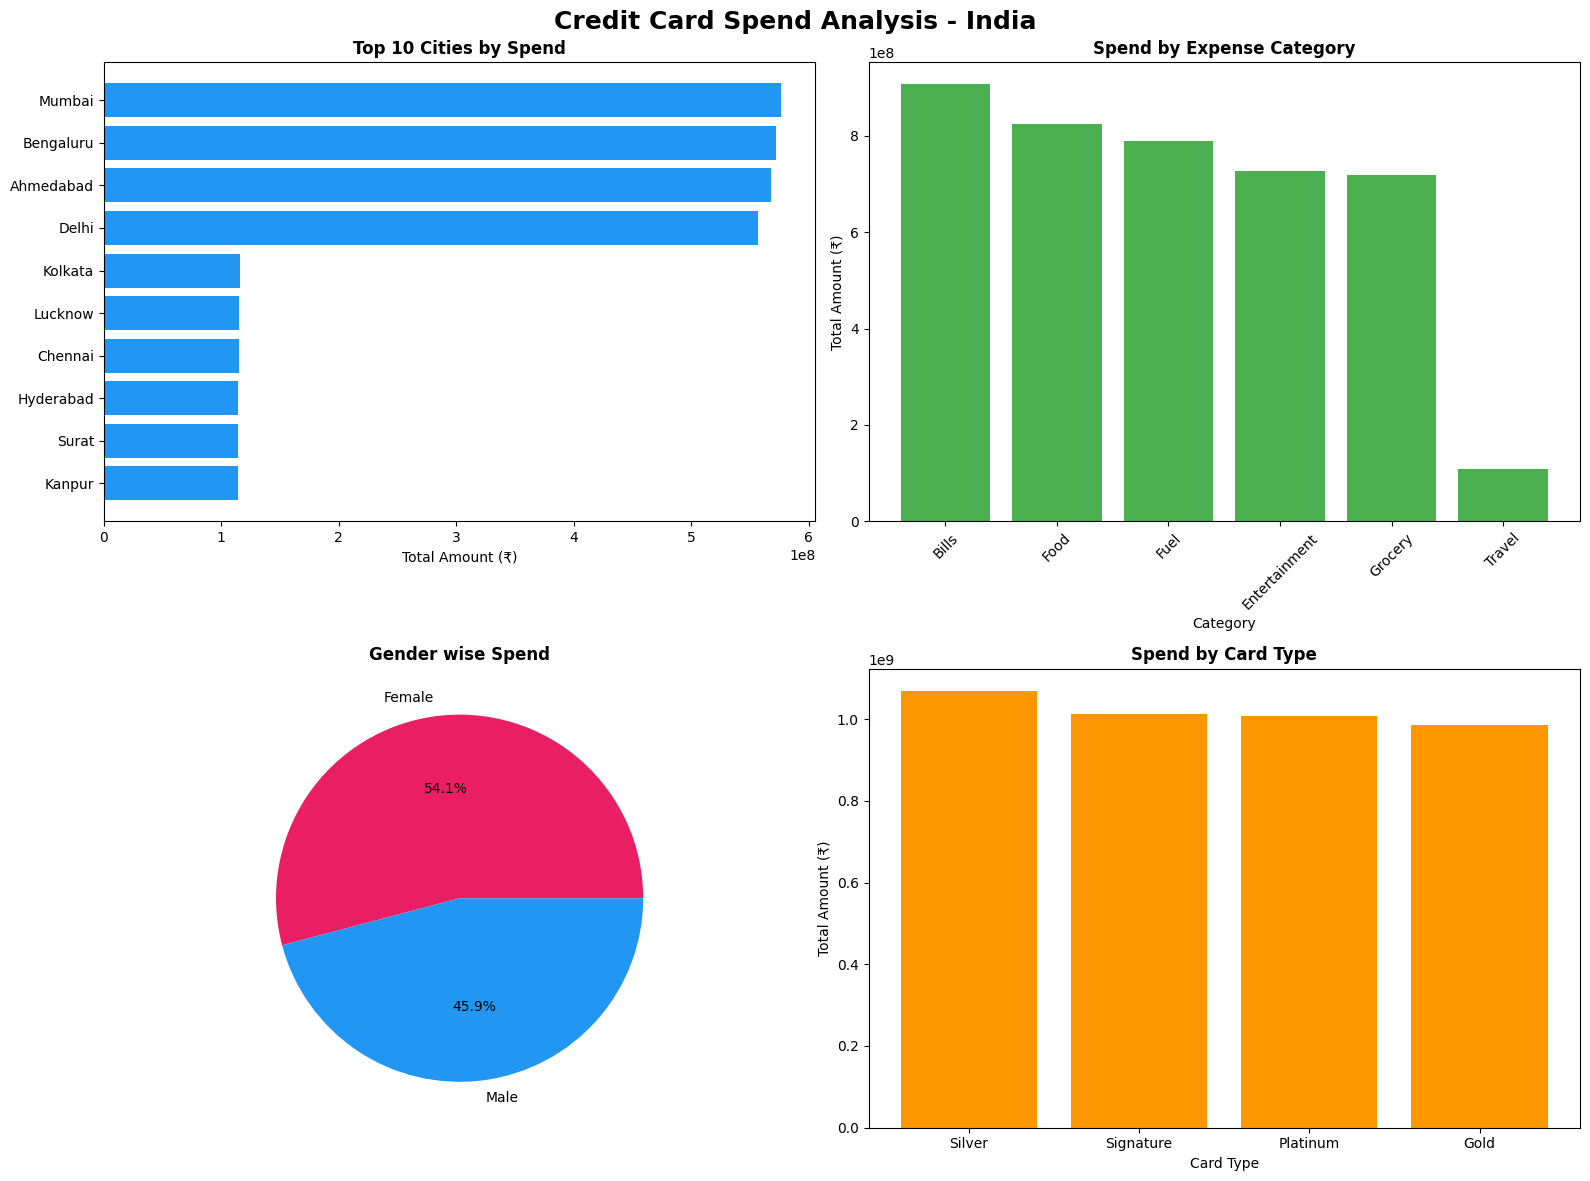

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Credit Card Spend Analysis - India', fontsize=18, fontweight='bold')

# Chart 1 - Top 10 Cities
city_spend = df.groupby('City')['Amount'].sum().sort_values(ascending=False).head(10)
axes[0,0].barh(city_spend.index[::-1], city_spend.values[::-1], color='#2196F3')
axes[0,0].set_title('Top 10 Cities by Spend', fontweight='bold')
axes[0,0].set_xlabel('Total Amount (₹)')

# Chart 2 - Expense Category
exp_spend = df.groupby('Exp Type')['Amount'].sum().sort_values(ascending=False)
axes[0,1].bar(exp_spend.index, exp_spend.values, color='#4CAF50')
axes[0,1].set_title('Spend by Expense Category', fontweight='bold')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Total Amount (₹)')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - Gender wise
gender_spend = df.groupby('Gender')['Amount'].sum()
axes[1,0].pie(gender_spend.values, labels=['Female','Male'],
              autopct='%1.1f%%', colors=['#E91E63','#2196F3'])
axes[1,0].set_title('Gender wise Spend', fontweight='bold')

# Chart 4 - Card Type
card_spend = df.groupby('Card Type')['Amount'].sum().sort_values(ascending=False)
axes[1,1].bar(card_spend.index, card_spend.values, color='#FF9800')
axes[1,1].set_title('Spend by Card Type', fontweight='bold')
axes[1,1].set_xlabel('Card Type')
axes[1,1].set_ylabel('Total Amount (₹)')

plt.tight_layout()
plt.savefig('creditcard_analysis.png', dpi=150)
plt.show()

**Monthly Charts Trend**

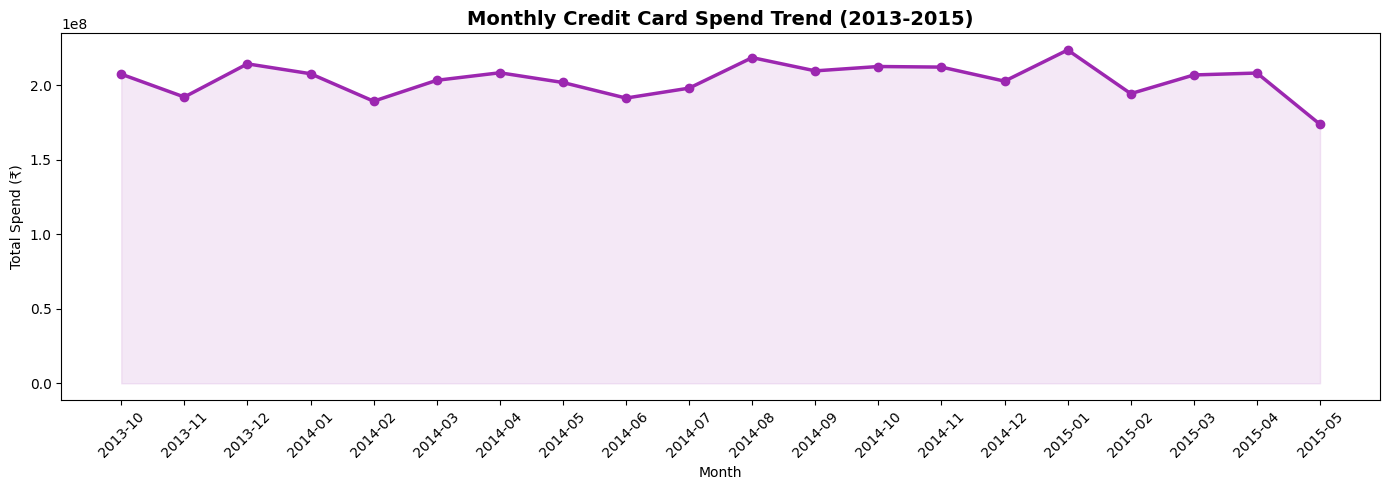

In [4]:
monthly = df.groupby('Month')['Amount'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Month'], monthly['Amount'],
         marker='o', color='#9C27B0', linewidth=2.5)
plt.fill_between(range(len(monthly)), monthly['Amount'],
                 alpha=0.1, color='#9C27B0')
plt.xticks(range(len(monthly)), monthly['Month'], rotation=45)
plt.title('Monthly Credit Card Spend Trend (2013-2015)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Spend (₹)')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()